In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util

DPI = 300
CMAP = "RdPu"

FOLDER = "/Users/brendan/Projects/trails/data/"


datafiles = [
    "scenarios|2026-02-11/data.json",
]

# smallexample = "example-small|2026-01-23/data.json"

In [2]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

ratios: [100.0 400.0 200.0 800.0 1600.0]
patch recovery: [0.001]
max costs: [2.0 8.0]
boundary conditions: ['PERIODIC']
num locations: [8]
random walker seeds: 2
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_DYNAMIC' 'CENTRAL_PLACE' 'WALL_TO_WALL']
settings.X : [100 200]
steps: 100000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches', 'locations', 'walkers',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [25]:
df[df["settings.X"] == 200]

,averageTravelCost,averageTravelLength,totalImprovement,thresholdImprovement,steps,paths,weightedHeadings,avgHeading,avgSquareHeading,patches,...,settings.boundaryConditions,settings.numLocations,settings.randomSeedWalkers,settings.randomSeedLocations,settings.recoveryLogic,settings.improvementLogic,settings.searchStrategy,settings.scenario,settings.X,ratio
202,0.000000,0.000000,0.000000,0.0,0,[],[],0.000000,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,PERIODIC,8,1,1,LINEAR,LINEAR,KANAI_SUZUKI,RANDOM_DYNAMIC,200,400.0
203,0.000000,0.000000,2996.411583,0.0,1000,[],[],0.000000,0.000000,"[0.0627441722058058, 0.1515670039060374, 0.114...",...,PERIODIC,8,1,1,LINEAR,LINEAR,KANAI_SUZUKI,RANDOM_DYNAMIC,200,400.0
204,0.000000,0.000000,3432.285931,0.0,2000,[],[],0.000000,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,PERIODIC,8,1,1,LINEAR,LINEAR,KANAI_SUZUKI,RANDOM_DYNAMIC,200,400.0
205,0.000000,0.000000,3491.520161,0.0,3000,[],[],0.000000,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,PERIODIC,8,1,1,LINEAR,LINEAR,KANAI_SUZUKI,RANDOM_DYNAMIC,200,400.0
206,0.000000,0.000000,3465.395490,0.0,4000,[],[],0.000000,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,PERIODIC,8,1,1,LINEAR,LINEAR,KANAI_SUZUKI,RANDOM_DYNAMIC,200,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7267,0.000000,0.000000,784.312258,0.0,96000,[],[],0.000000,0.000000,"[0.959, 0.959, 0.959, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,PERIODIC,8,2,1,LINEAR,LINEAR,KANAI_SUZUKI,WALL_TO_WALL,200,1600.0
7268,0.000000,0.000000,780.281746,0.0,97000,[],[],0.000000,0.000000,"[0.995, 0.995, 0.9944326792325051, 0.0, 0.0, 0...",...,PERIODIC,8,2,1,LINEAR,LINEAR,KANAI_SUZUKI,WALL_TO_WALL,200,1600.0
7269,0.000000,0.000000,781.075317,0.0,98000,[],[],0.000000,0.000000,"[0.985, 0.985, 0.985, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,PERIODIC,8,2,1,LINEAR,LINEAR,KANAI_SUZUKI,WALL_TO_WALL,200,1600.0
7270,0.000000,0.000000,781.739010,0.0,99000,[],[],0.000000,0.000000,"[0.9949493200470636, 0.9944383783201507, 0.994...",...,PERIODIC,8,2,1,LINEAR,LINEAR,KANAI_SUZUKI,WALL_TO_WALL,200,1600.0


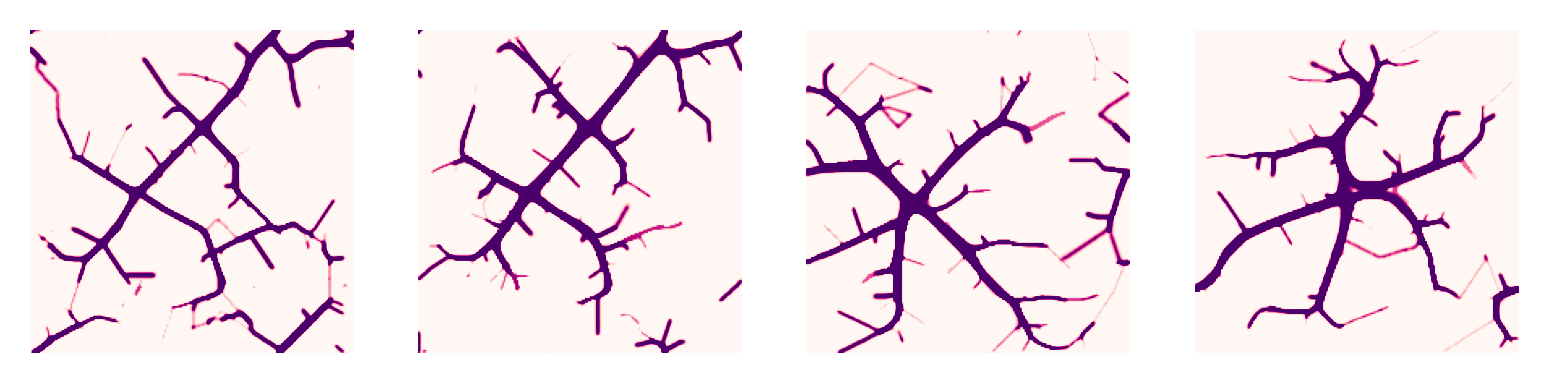

In [60]:
SNAPSHOTS = [1000, 2000, 10000, 100000]
X = 200

_df = df[
    (df["settings.scenario"] == "RANDOM_DYNAMIC") &
    (df["settings.maxCost"] == 8.0) &
    (df["ratio"] == 400.0) &
    (df["settings.randomSeedWalkers"] == 1) &
    (df["settings.X"] == X) &
    (df["settings.boundaryConditions"] == "PERIODIC")
]

MARKER_SIZE = 8 

# ly = [p[1] for p in df_small["locations"][0]]
# lx = [p[0] for p in df_small["locations"][0]]

# STEPS = np.linspace(START, END, num=3)
fig, axs = plt.subplots(1, len(SNAPSHOTS), dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(SNAPSHOTS):
    row = _df[(_df["steps"] == steps)].iloc[0]
    
    
    axs[i].imshow(np.reshape(row["patches"], (X, X)), cmap=CMAP, vmin=0, vmax=.4)
    axs[i].axis('off')
    # axs[i].set_title(steps)
    # axs[i].scatter(lx, ly, s=MARKER_SIZE)
    
    # wy = [p[1] for p in row["walkers"]]
    # wx = [p[0] for p in row["walkers"]]
    # axs[i].scatter(wx, wy, marker="^", s=MARKER_SIZE)


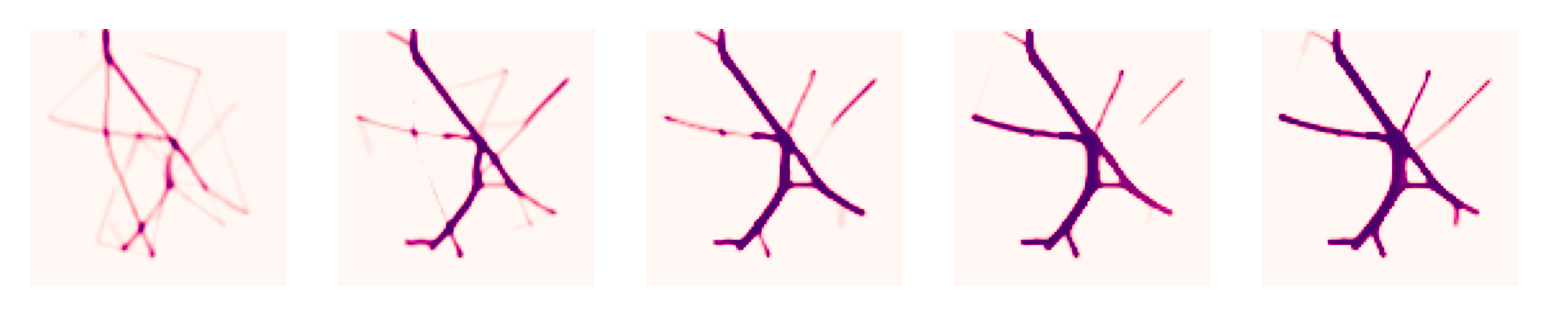

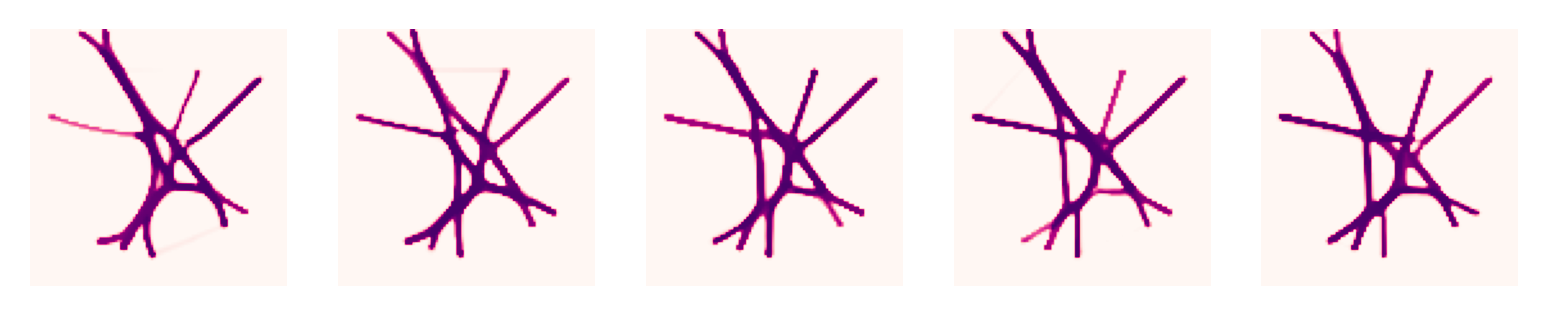

In [86]:
MID = 2000
END = 20000

STEPS = np.linspace(0, MID, num=6)
fig, axs = plt.subplots(1, 5, dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(STEPS[1:]):
    row = df[(df["steps"] == steps)].iloc[0]
    axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
    axs[i].axis('off')

STEPS = np.linspace(MID, END, num=6)
fig, axs = plt.subplots(1, 5, dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(STEPS[1:]):
    row = df[(df["steps"] == steps)].iloc[0]
    axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
    axs[i].axis('off')